# MindBridge — Exploratory Data Analysis
### Step 2: Understanding the Data

> **Goal:** Explore the dataset to uncover patterns, class distributions, text characteristics, and key insights before modeling.

---

| Section | What We Explore |
|---------|----------------|
| 1. Dataset Overview | Shape, types, missing values |
| 2. Summary Stats Table | Per-class statistics |
| 3. Class Distribution | Balance across 7 mental health classes |
| 4. Text Length Analysis | Word and character count patterns |
| 5. Top 15 Words | Most discriminative words per class |
| 6. Word Clouds | Visual word frequency per class |
| 7. Key Insights | Findings and next steps |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from IPython.display import display, HTML
import nltk
import warnings
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/data/Combined Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print(f"  Total Samples     : {len(df):,}")
print(f"  Total Columns     : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : 0")
print(f"  Classes           : {df['status'].nunique()}")
print()
for cls in sorted(df['status'].unique()):
    count = (df['status'] == cls).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"   {cls:<25} {count:>5,}  ({pct:.1f}%)  {bar}")

  Total Samples     : 51,093
  Total Columns     : 2
  Missing Values    : 0
  Duplicate Rows    : 0
  Classes           : 7

   Anxiety                   3,623  (7.1%)  ███
   Bipolar                   2,501  (4.9%)  ██
   Depression                15,094  (29.5%)  ██████████████
   Normal                    16,040  (31.4%)  ███████████████
   Personality disorder        895  (1.8%)  
   Stress                    2,296  (4.5%)  ██
   Suicidal                  10,644  (20.8%)  ██████████


## 1. Summary Statistics by Class

In [3]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))

summary = df.groupby('status').agg(
    Count=('statement', 'count'),
    Avg_Words=('word_count', 'mean'),
    Max_Words=('word_count', 'max'),
    Min_Words=('word_count', 'min')
).reset_index()
summary['Percentage'] = (summary['Count'] / summary['Count'].sum() * 100).round(1)
summary['Avg_Words'] = summary['Avg_Words'].round(0).astype(int)
summary = summary.sort_values('Count', ascending=False)
summary.columns = ['Class', 'Count', 'Avg Words', 'Max Words', 'Min Words', '% of Data']
summary = summary[['Class', 'Count', '% of Data', 'Avg Words', 'Max Words', 'Min Words']]

summary.style\
    .background_gradient(cmap='Blues', subset=['Count'])\
    .background_gradient(cmap='Oranges', subset=['Avg Words'])\
    .bar(subset=['% of Data'], color='#4ECDC4')\
    .format({'% of Data': '{:.1f}%', 'Count': '{:,}'})\
    .set_properties(**{'font-size': '13px', 'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#764ba2'), ('color', 'white'),
                  ('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]
    }])

,Class,Count,% of Data,Avg Words,Max Words,Min Words
3,Normal,"16,040",31.4%,17,255,1
2,Depression,"15,094",29.5%,168,4239,1
6,Suicidal,"10,644",20.8%,147,6300,1
0,Anxiety,"3,623",7.1%,143,1592,1
1,Bipolar,"2,501",4.9%,178,4804,4
5,Stress,"2,296",4.5%,112,1606,1
4,Personality disorder,895,1.8%,178,5419,5


## 2. Class Distribution

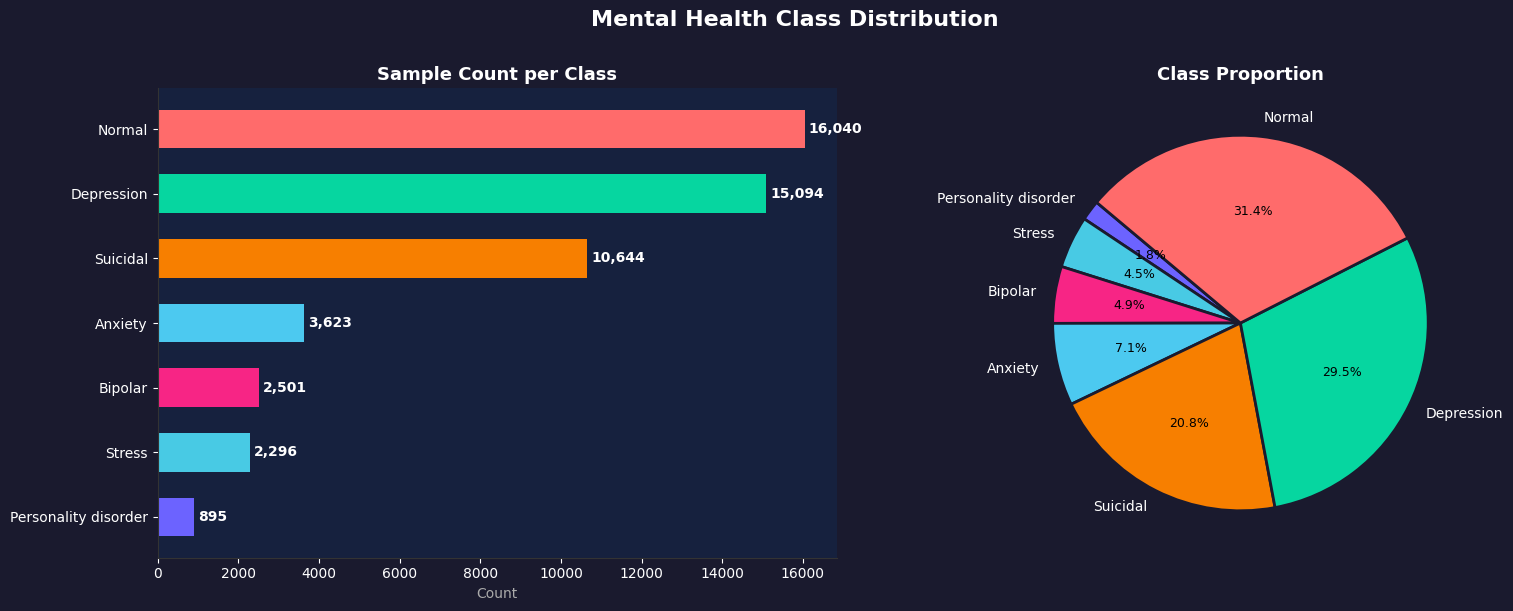

Saved: results/plots/class_distribution.png


In [4]:
COLORS = ['#6C63FF','#48CAE4','#f72585','#4cc9f0','#f77f00','#06d6a0','#ff6b6b']
class_counts = df['status'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Mental Health Class Distribution', fontsize=16, fontweight='bold', color='white', y=1.01)

ax1 = axes[0]
ax1.set_facecolor('#16213e')
bars = ax1.barh(class_counts.index, class_counts.values,
                color=COLORS, height=0.6, edgecolor='none')
for bar, val in zip(bars, class_counts.values):
    ax1.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, color='white', fontweight='bold')
ax1.set_title('Sample Count per Class', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Count', color='#aaa')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#333')
ax1.spines['left'].set_color('#333')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color('white')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
wedges, texts, autotexts = ax2.pie(
    class_counts.values, labels=class_counts.index,
    colors=COLORS, autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2})
for text in texts: text.set_color('white')
for at in autotexts: at.set_fontsize(9)
ax2.set_title('Class Proportion', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Saved: results/plots/class_distribution.png")

## 3. Text Length Analysis

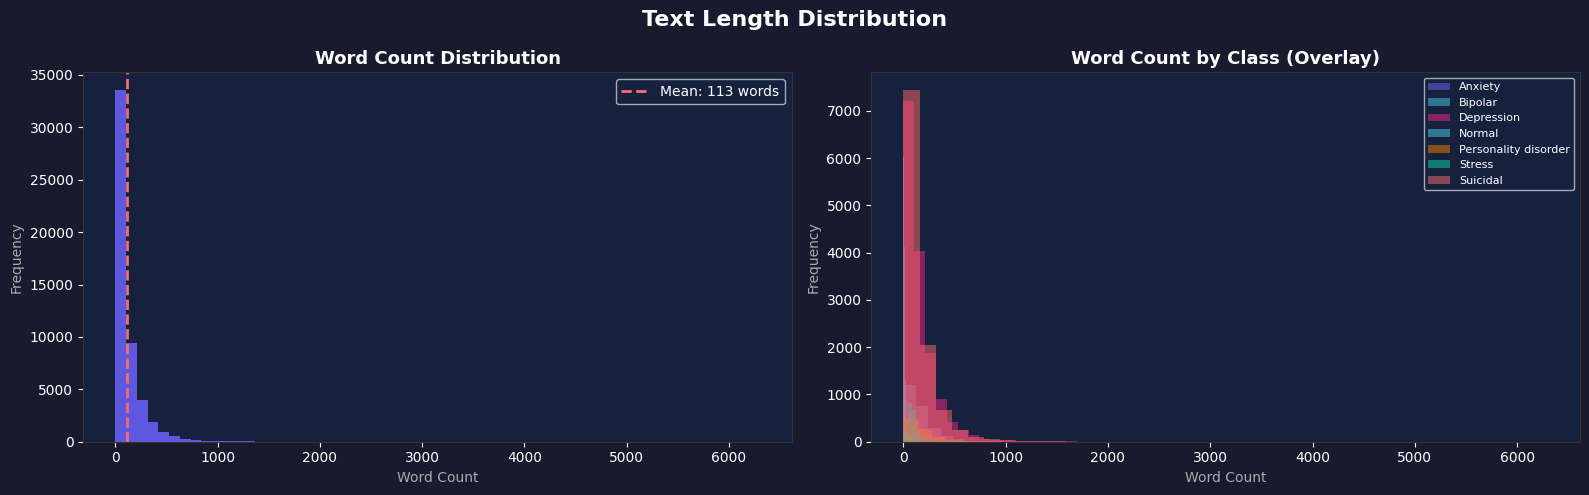

Avg word count: 113 | Max: 6300 | Min: 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Text Length Distribution', fontsize=16, fontweight='bold', color='white')

axes[0].set_facecolor('#16213e')
axes[0].hist(df['word_count'], bins=60, color='#6C63FF', alpha=0.85, edgecolor='none')
axes[0].axvline(df['word_count'].mean(), color='#ff6b6b', linewidth=2,
                linestyle='--', label=f"Mean: {df['word_count'].mean():.0f} words")
axes[0].set_title('Word Count Distribution', color='white', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count', color='#aaa')
axes[0].set_ylabel('Frequency', color='#aaa')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#16213e', labelcolor='white')
for spine in axes[0].spines.values(): spine.set_color('#333')

classes = sorted(df['status'].unique())
axes[1].set_facecolor('#16213e')
for cls, color in zip(classes, COLORS):
    subset = df[df['status'] == cls]['word_count']
    axes[1].hist(subset, bins=40, alpha=0.5, label=cls, color=color, edgecolor='none')
axes[1].set_title('Word Count by Class (Overlay)', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count', color='#aaa')
axes[1].set_ylabel('Frequency', color='#aaa')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#16213e', labelcolor='white', fontsize=8)
for spine in axes[1].spines.values(): spine.set_color('#333')

plt.tight_layout()
plt.savefig('results/plots/text_length.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f"Avg word count: {df['word_count'].mean():.0f} | Max: {df['word_count'].max()} | Min: {df['word_count'].min()}")

## 4. Top 15 Most Frequent Words per Class

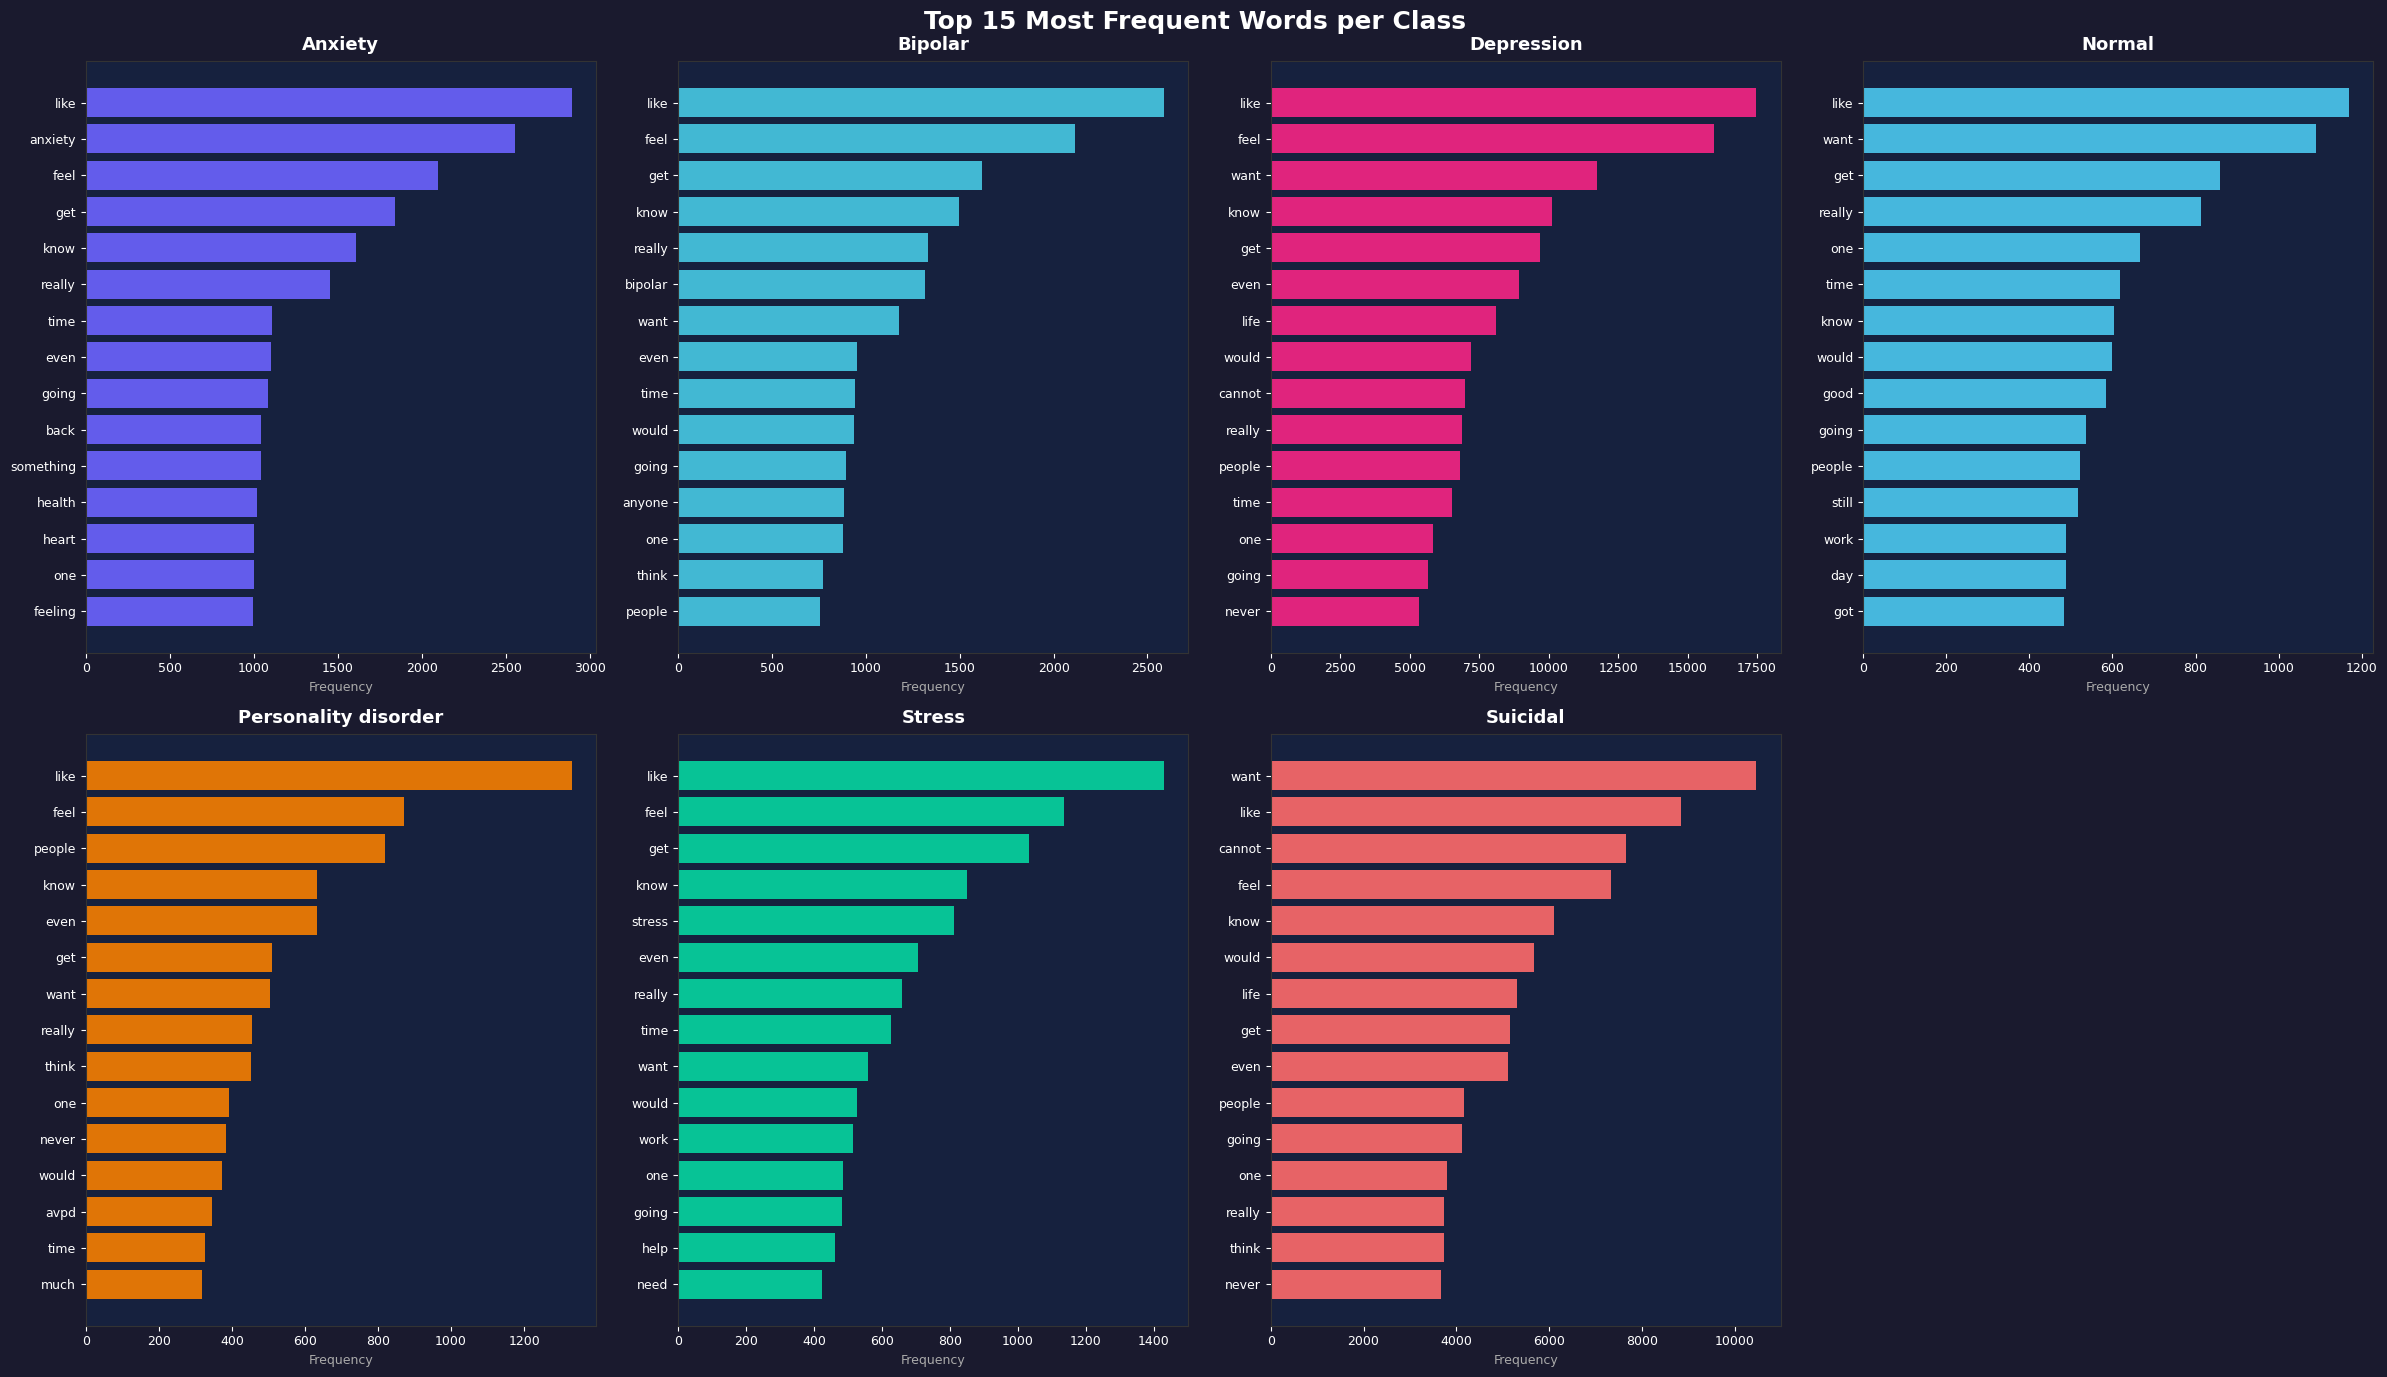

Saved: results/plots/top_words_per_class.png


In [6]:
stop_words = set(stopwords.words('english'))
classes = sorted(df['status'].unique())

fig, axes = plt.subplots(2, 4, figsize=(24, 14))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Top 15 Most Frequent Words per Class', fontsize=18, fontweight='bold', color='white')
axes = axes.flatten()

for i, (cls, color) in enumerate(zip(classes, COLORS)):
    texts = ' '.join(df[df['status'] == cls]['statement'].astype(str)).lower()
    words = [w for w in texts.split() if w.isalpha() and w not in stop_words and len(w) > 2]
    top_words = Counter(words).most_common(15)
    words_list, counts = zip(*top_words)

    axes[i].set_facecolor('#16213e')
    bars = axes[i].barh(list(words_list)[::-1], list(counts)[::-1],
                        color=color, edgecolor='none', alpha=0.9)
    axes[i].set_title(cls, fontsize=13, fontweight='bold', color='white', pad=8)
    axes[i].set_xlabel('Frequency', color='#aaa', fontsize=9)
    axes[i].tick_params(colors='white', labelsize=9)
    for spine in axes[i].spines.values(): spine.set_color('#333')
    axes[i].figure.set_facecolor('#1a1a2e')

axes[7].set_facecolor('#1a1a2e')
axes[7].axis('off')

plt.tight_layout()
plt.savefig('results/plots/top_words_per_class.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: results/plots/top_words_per_class.png")

## 5. Word Clouds by Class

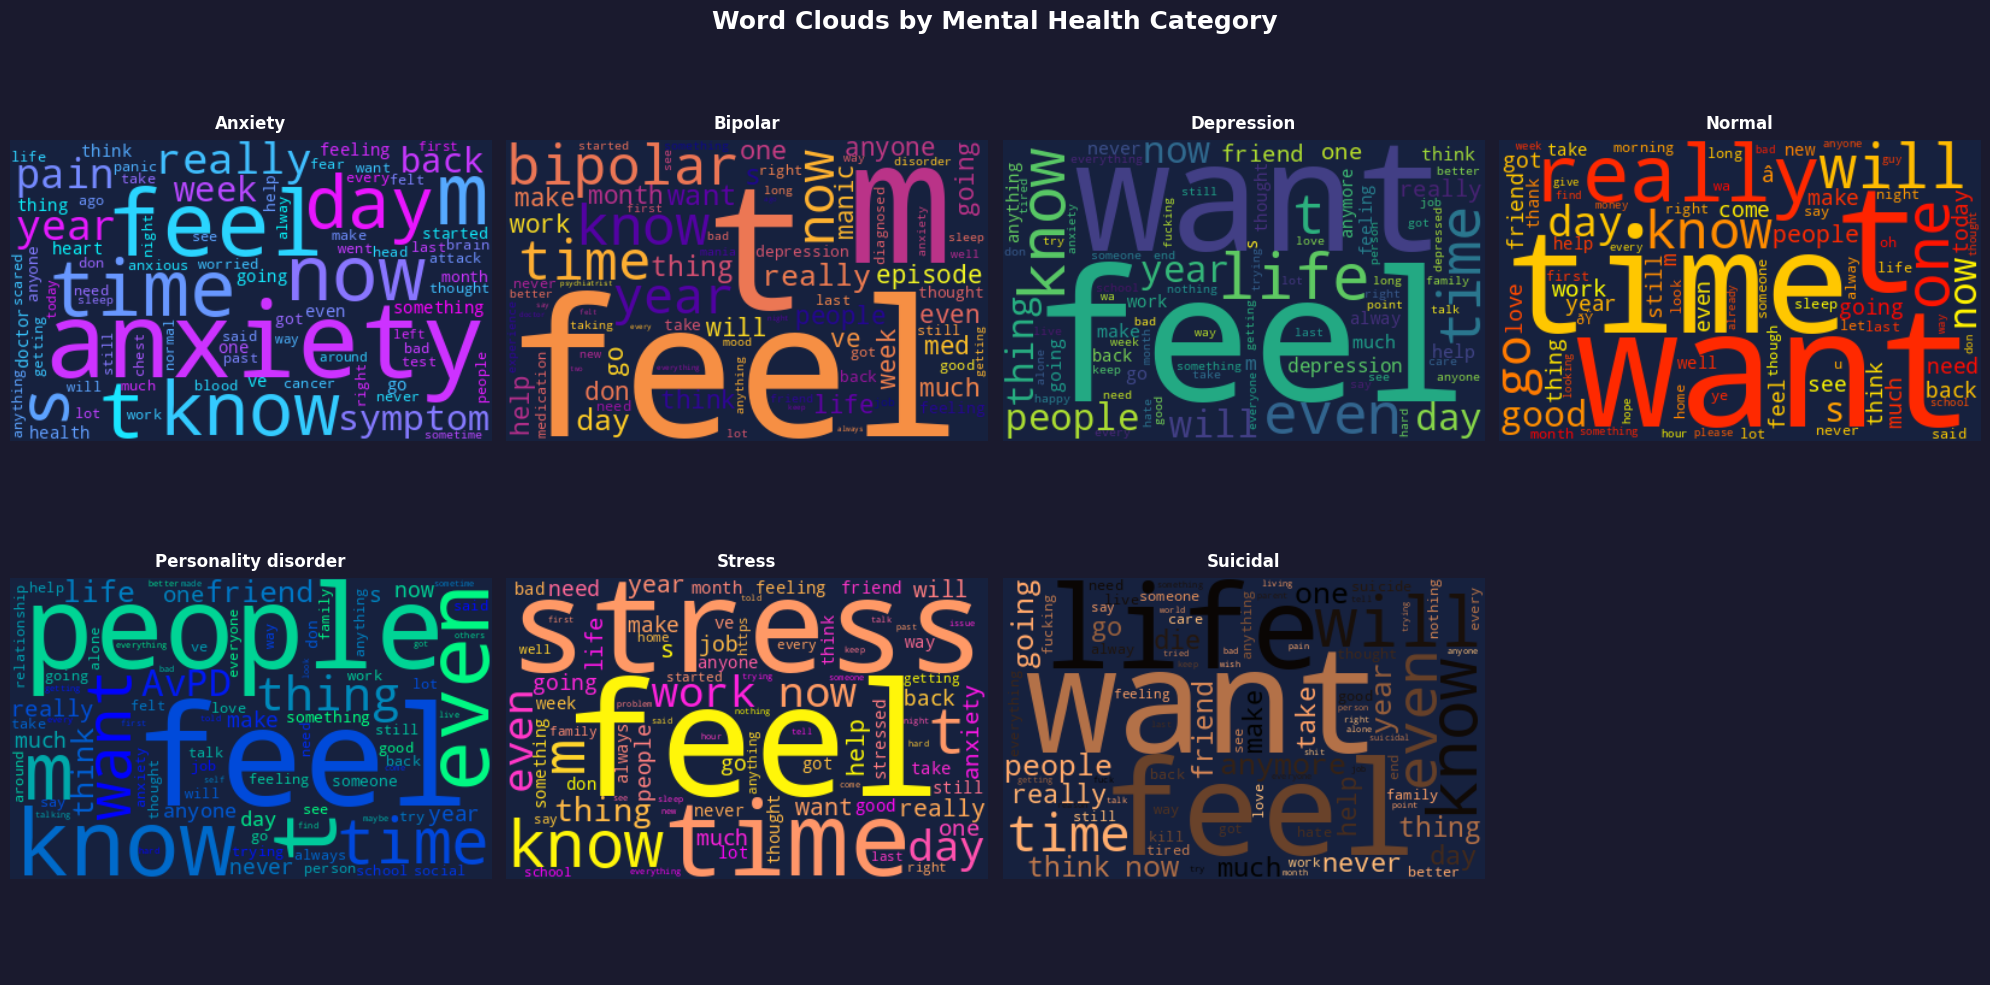

Saved: results/plots/wordclouds.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Word Clouds by Mental Health Category', fontsize=18, fontweight='bold', color='white')
axes = axes.flatten()

colormaps = ['cool','plasma','viridis','autumn','winter','spring','copper']

for i, (cls, cmap) in enumerate(zip(sorted(df['status'].unique()), colormaps)):
    text = ' '.join(df[df['status'] == cls]['statement'].astype(str).tolist())
    wc = WordCloud(
        width=400, height=250,
        background_color='#16213e',
        colormap=cmap,
        max_words=80,
        collocations=False,
        prefer_horizontal=0.85
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cls, fontsize=12, fontweight='bold', color='white', pad=8)
    axes[i].axis('off')
    axes[i].set_facecolor('#1a1a2e')

axes[7].axis('off')
axes[7].set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig('results/plots/wordclouds.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: results/plots/wordclouds.png")

## 6. Class Imbalance Analysis

### Why This Matters

The dataset has a **13:1 imbalance ratio** between the largest class (Normal: 30.8%) and smallest (Personality Disorder: 2.3%).

| Problem | Impact | Solution |
|---------|--------|----------|
| Majority class dominates training | Model ignores minority classes | `class_weight='balanced'` |
| Low recall on rare classes | Personality Disorder F1 will be low | SMOTE oversampling |
| Accuracy metric is misleading | 30% accuracy just by predicting Normal | Use **Weighted F1** as primary metric |

> **Decision:** We will use `class_weight='balanced'` in all models and report **Weighted F1** as the primary evaluation metric.

## 7. Average Word Count per Class

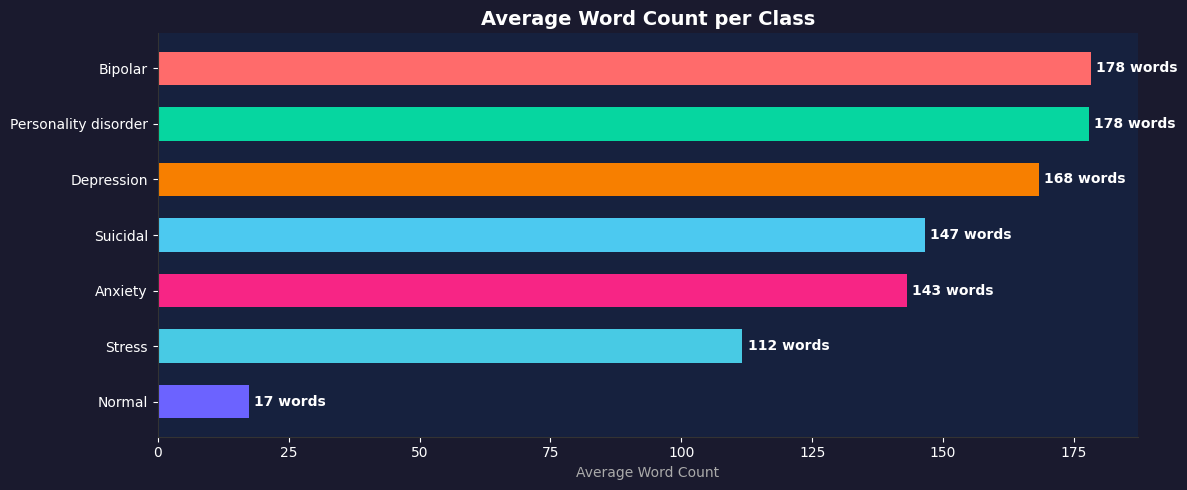

Key insight: Bipolar posts are longest (~178 words), Normal posts are shortest (~17 words)


In [8]:
avg_words = df.groupby('status')['word_count'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

bars = ax.barh(avg_words.index, avg_words.values, color=COLORS, edgecolor='none', height=0.6)
for bar, val in zip(bars, avg_words.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} words', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_title('Average Word Count per Class', color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Word Count', color='#aaa')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color('white')

plt.tight_layout()
plt.savefig('results/plots/avg_words_per_class.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Key insight: Bipolar posts are longest (~178 words), Normal posts are shortest (~17 words)")

## Step 2 Complete — Key EDA Insights

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~51,000 samples after cleaning |
| **Class Imbalance** | Yes — Normal (30.8%) and Depression (29.2%) dominate |
| **Avg Text Length** | ~113 words per statement |
| **Shortest Texts** | Normal class (~17 words avg) |
| **Longest Texts** | Bipolar class (~178 words avg) |
| **Richest Vocabulary** | Depression and Bipolar show most diverse word usage |

### Key Challenges Identified
- Class imbalance — will use `class_weight='balanced'` in all models
- High text length variance — TF-IDF with sublinear scaling will normalize this
- Overlapping vocabulary between classes — SVM expected to handle best

### Next Step: 02_Preprocessing.ipynb
- Clean text (lowercase, punctuation, stopwords, lemmatization)
- TF-IDF vectorization with unigrams + bigrams